## Understanding K-Means Clusterng
**K-Means** is a popular unsupervised machine learning algorithm used for clustering data into distinct groups based on their similarities. The main goal of K-Means is to partition a dataset into *K* distinct, non-overlapping clusters, where each data point belongs to the cluster with the nearest mean (centroid).
 
### How Does K-Means Work?
1. **Initialization**: Choose the number of clusters (*K*) and randomly initialize *K* centroids.
2. **Assignment Step**: Assign each data point to the nearest centroid, forming *K* clusters.
3. **Update Step**: Recalculate the centroids as the mean of all data points assigned to each cluster.
4. **Repeat**: Repeat the assignment and update steps until the centroids no longer change significantly or a maximum number of iterations is reached.
 
### Basic Terminologies
- **Cluster**: A group of data points aggregated together because of certain similarities.
- **Centroid**: The center of a cluster; it is the mean position of all the points in the cluster.
- **Inertia**: The sum of squared distances between each data point and its assigned centroid; used to evaluate how well the clusters are formed.
- **WSCSS (Within-Cluster Sum of Squares)**: The total squared distance between each point and the centroid of its assigned cluster; a measure of cluster compactness (also known as inertia).
- **K-Means++**: An improved method for initializing centroids in K-Means that spreads out the initial cluster centers, often leading to better clustering results and faster convergence.
- **Convergence**: The point at which the centroids no longer move significantly, indicating that the algorithm has finished. 

K-Means is widely used for customer segmentation, image compression, and pattern recognition due to its simplicity and efficiency.


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=100)

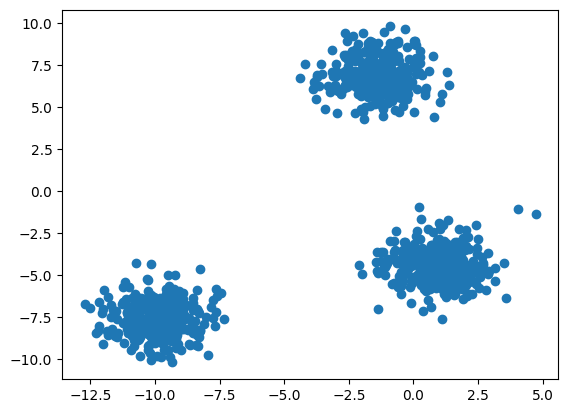

In [10]:
plt.scatter(X[:,0],X[:,1])

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=101)

In [13]:
from sklearn.cluster import KMeans

### Manual process to find K value using Elbow Method

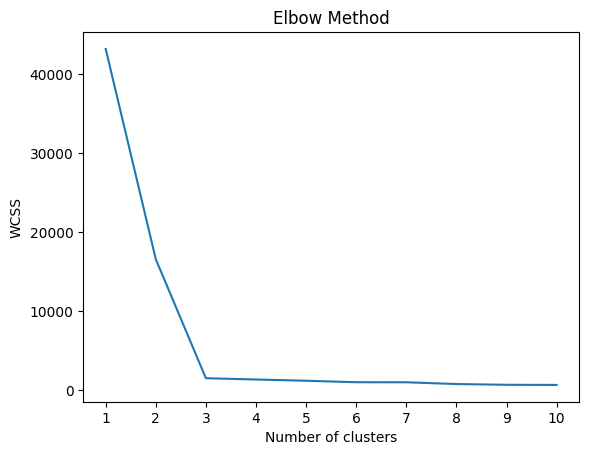

In [16]:
wscss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wscss.append(kmeans.inertia_)

plt.plot(range(1,11),wscss)
plt.title('Elbow Method')
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


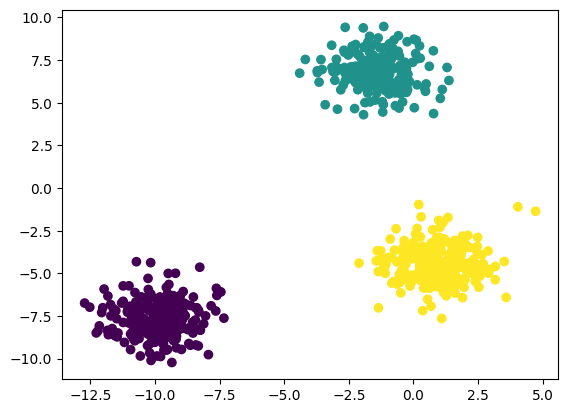

In [17]:
kmeans = KMeans(n_clusters=3)
y_labels =kmeans.fit_predict(X_train)

plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

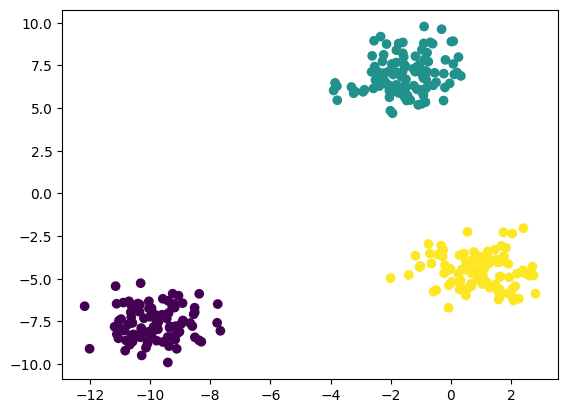

In [18]:
test_labels = kmeans.predict(X_test)
plt.scatter(X_test[:,0],X_test[:,1],c=test_labels)

### Finding K value using knee locater (sklearn)

In [19]:
!pip install kneed

In [20]:
from kneed import KneeLocator

In [ ]:
kl = KneeLocator(range(1,11),wscss,curve = 'convex', direction='decreasing') ## convex means the curve is increasing and decreasing means the curve is decreasing
kl.elbow

np.int64(3)

### Performance Metrics

In [24]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_scores.append(score)

In [26]:
silhouette_scores

[np.float64(0.6273416957589362),
 np.float64(0.8343725852992101),
 np.float64(0.6650337720417312),
 np.float64(0.49327260077446966),
 np.float64(0.31341648812670336),
 np.float64(0.3199585331091415),
 np.float64(0.3190481289306368),
 np.float64(0.322865365087106),
 np.float64(0.3301293300398771)]

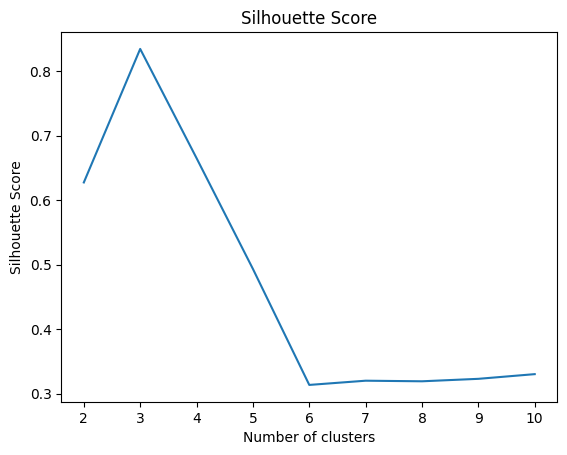

In [28]:
plt.plot(range(2,11),silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2,11))
plt.title('Silhouette Score')
plt.show()